# For numerical values 
###    -univariate imputation
###    -Multivariate imputation

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


## Techniques
####    - Mean/Median
####    - Aribtary
####    - End of distribution
####    - random

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [4]:
df = pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/titanic_toy.csv')

In [5]:
df.sample(5)

,Age,Fare,Family,Survived
510,29.0,7.7500,0,1
632,32.0,30.5000,0,1
118,24.0,247.5208,1,0
872,33.0,5.0000,0,0
885,39.0,29.1250,5,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [7]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [8]:
x=df.drop(columns=['Survived'])
y =df['Survived']

In [9]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [10]:
x_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [12]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median() 


mean_age = x_train['Fare'].mean() 
median_age = x_train['Fare'].median() 

In [13]:
x_train['Age_median']=x_train['Age'].fillna(median_age)
x_train['Age_mean']=x_train['Age'].fillna(mean_age)

x_train['Fare_median']=x_train['Fare'].fillna(median_age)
x_train['Fare_mean']=x_train['Fare'].fillna(mean_age)

In [14]:
x_train

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
30,40.0,27.7208,0,40.0000,40.000000,27.7208,27.7208
10,4.0,16.7000,2,4.0000,4.000000,16.7000,16.7000
873,47.0,9.0000,0,47.0000,47.000000,9.0000,9.0000
182,9.0,31.3875,6,9.0000,9.000000,31.3875,31.3875
876,20.0,9.8458,0,20.0000,20.000000,9.8458,9.8458
...,...,...,...,...,...,...,...
534,30.0,8.6625,0,30.0000,30.000000,8.6625,8.6625
584,NaN,8.7125,0,14.4583,32.617597,8.7125,8.7125
493,71.0,49.5042,0,71.0000,71.000000,49.5042,49.5042
527,NaN,221.7792,0,14.4583,32.617597,221.7792,221.7792


In [15]:
print('Orginal Age variable variance:',x_train['Age'].var())
print(' Age variable variance after mean imputation:',x_train['Age_mean'].var())
print(' Age variable variance after median imputation:',x_train['Age_median'].var())


print('Orginal Age variable variance:',x_train['Age'].var())
print('Age variable variance after mean imputation:',x_train['Age_mean'].var())
print('Age variable variance after median imputation:',x_train['Age_median'].var())

Orginal Age variable variance: 204.3495133904614
 Age variable variance after mean imputation: 163.1347828052615
 Age variable variance after median imputation: 200.55085535155024
Orginal Age variable variance: 204.3495133904614
Age variable variance after mean imputation: 163.1347828052615
Age variable variance after median imputation: 200.55085535155024


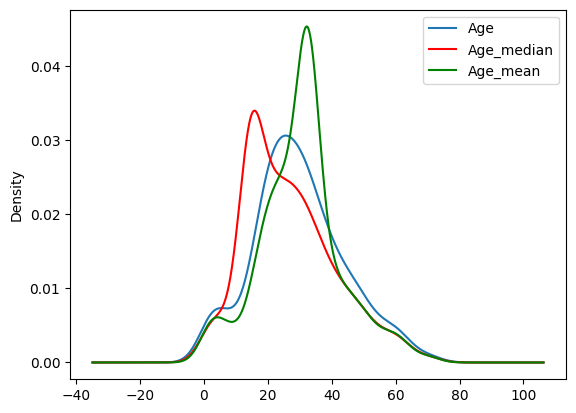

In [16]:
fig =plt.figure()
ax= fig.add_subplot(111)
# original
x_train['Age'].plot(kind='kde',ax=ax)

# after median imputed
x_train['Age_median'].plot(kind='kde',ax=ax,color='red')

#after mean imputation
x_train['Age_mean'].plot(kind='kde',ax=ax,color='green')

# add legends
lines, labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

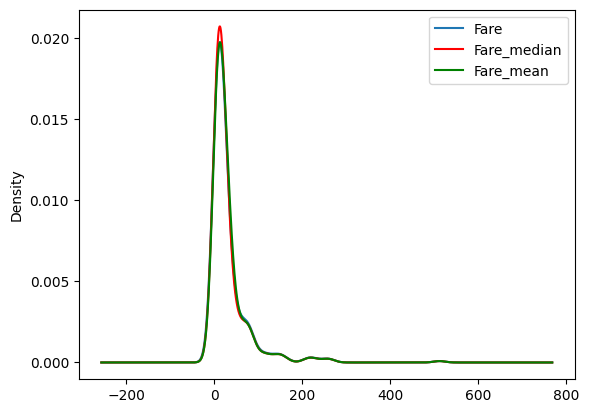

In [17]:
fig =plt.figure()
ax= fig.add_subplot(111)
# original
x_train['Fare'].plot(kind='kde',ax=ax)

# after median imputed
x_train['Fare_median'].plot(kind='kde',ax=ax,color='red')

#after mean imputation
x_train['Fare_mean'].plot(kind='kde',ax=ax,color='green')

# add legends
lines, labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [18]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,90.432552,49.169279,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-4.649792,-5.237797,16.476305,16.385048
Age_median,204.349513,90.432552,-4.649792,200.550855,154.655944,83.842733,85.853688
Age_mean,204.349513,49.169279,-5.237797,154.655944,163.134783,45.356620,46.679696
Fare_median,64.858859,2448.197914,16.476305,83.842733,45.356620,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,85.853688,46.679696,2324.238526,2324.238526


In [19]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.128809,0.077538,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.198528,-0.247957,0.205942,0.205499
Age_median,1.000000,0.128809,-0.198528,1.000000,0.855029,0.122387,0.125750
Age_mean,1.000000,0.077538,-0.247957,0.855029,1.000000,0.073409,0.075808
Fare_median,0.087356,1.000000,0.205942,0.122387,0.073409,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.125750,0.075808,0.996607,1.000000


<Axes: >

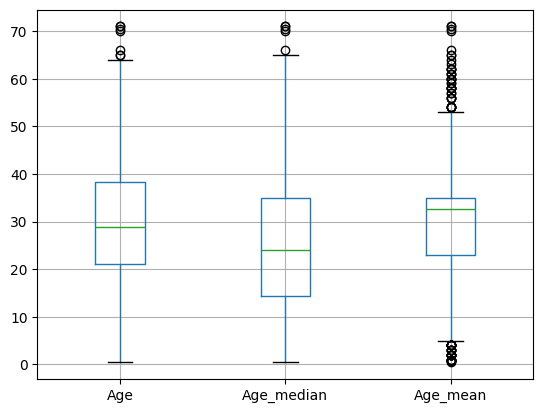

In [20]:
x_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

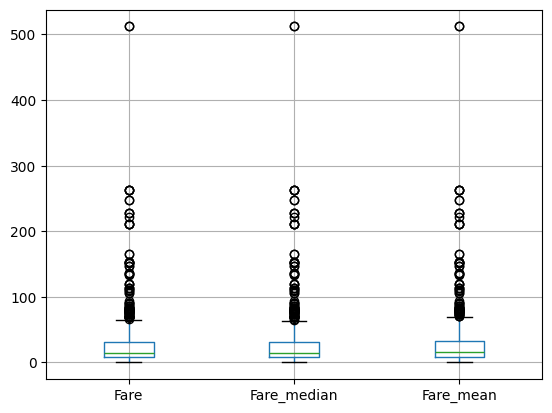

In [21]:
x_train[['Fare','Fare_median','Fare_mean']].boxplot()

# Using sklearn

In [22]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [23]:
imputer1 =SimpleImputer(strategy='median')
imputer2 =SimpleImputer(strategy='mean')

In [24]:
trf = ColumnTransformer([
    ('imputer1', imputer1,['Age']),
    ('imputer2', imputer2,['Fare'])
], remainder='passthrough')

In [25]:
trf.fit(x_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [26]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [27]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [28]:
x_train =trf.transform(x_train)
x_test =trf.transform(x_test)

In [29]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

# For categorical data

#### If more than 10% Nan data use mode to fill data.
#### If less than 10% use random value as missing and fill it.

In [35]:
ok=pd.read_csv('/Users/prajwalsubedi/Desktop/Data science/Data Sets/train.csv',usecols=['FireplaceQu','GarageQual','SalePrice'])

In [39]:
ok.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   FireplaceQu  770 non-null    object
 1   GarageQual   1379 non-null   object
 2   SalePrice    1460 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 34.3+ KB


In [40]:
ok.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of Houses')

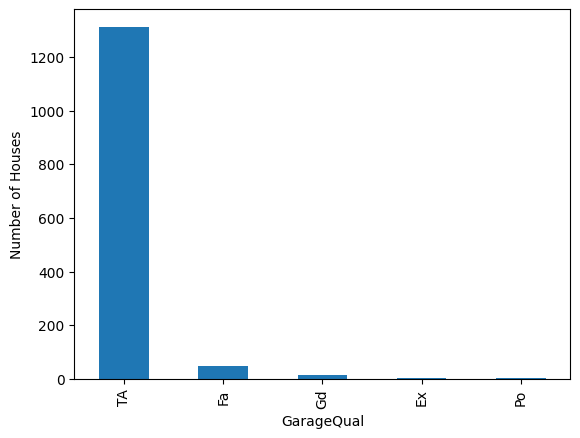

In [41]:
ok['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of Houses')

In [43]:
ok['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'GarageQual')

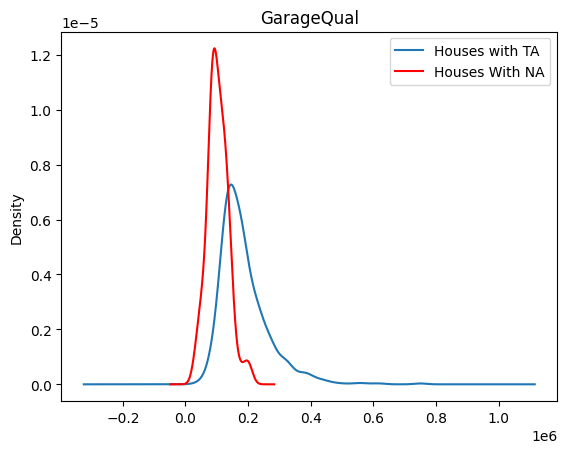

In [44]:
fig =plt.figure()
ax=fig.add_subplot(111)

ok[ok['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax)

ok[ok['GarageQual'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color = 'red') 

lines,labels= ax.get_legend_handles_labels()
labels=['Houses with TA','Houses With NA']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

In [45]:
temp = ok[ok['GarageQual']=='TA']['SalePrice']

In [46]:
ok['GarageQual'].fillna('TA',inplace=True)

<Axes: xlabel='GarageQual'>

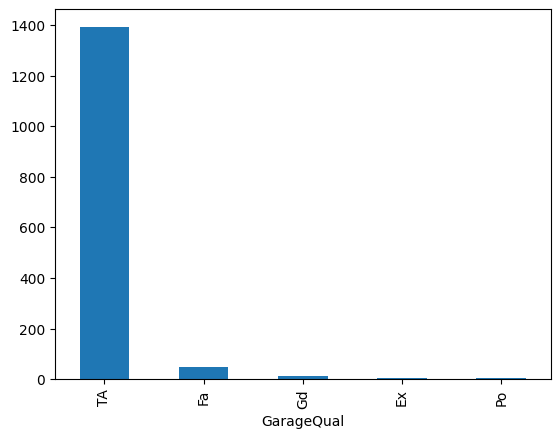

In [48]:
ok['GarageQual'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'GarageQual')

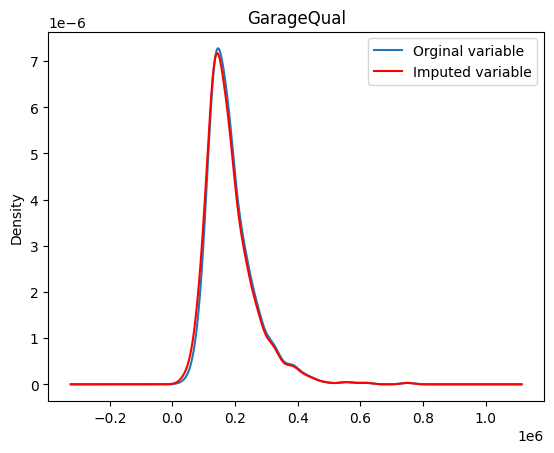

In [49]:
fig =plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

# distribution of the variable after imputation
ok[ok['GarageQual']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')



lines,labels= ax.get_legend_handles_labels()
labels=['Orginal variable','Imputed variable']
ax.legend(lines,labels,loc='best')

plt.title('GarageQual')

<Axes: xlabel='FireplaceQu'>

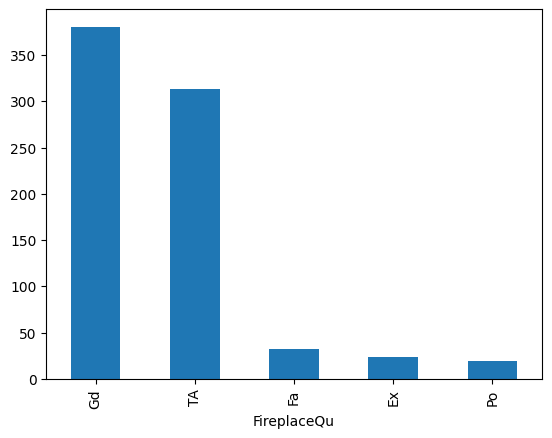

In [50]:
ok['FireplaceQu'].value_counts().sort_values(ascending=False).plot.bar()


In [51]:
ok['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireplaceQu')

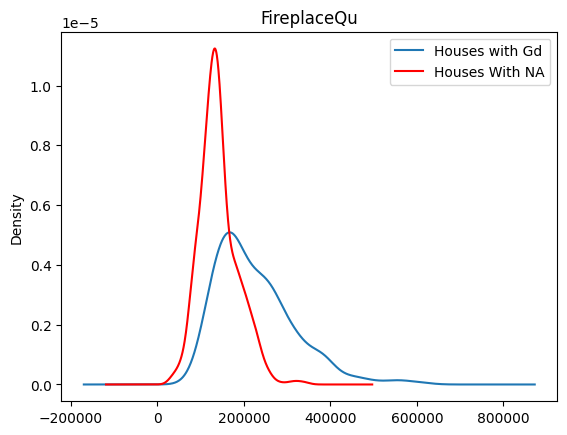

In [52]:
fig =plt.figure()
ax=fig.add_subplot(111)

ok[ok['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax)

ok[ok['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde',ax=ax,color = 'red') 

lines,labels= ax.get_legend_handles_labels()
labels=['Houses with Gd','Houses With NA']
ax.legend(lines,labels,loc='best')

plt.title('FireplaceQu')

In [54]:
temp = ok[ok['FireplaceQu']=='Gd']['SalePrice']

In [55]:
ok['FireplaceQu'].fillna('Gd',inplace=True)

/var/folders/nl/75k6nf4573d4dnj713sbnl5w0000gn/T/ipykernel_99131/3944691545.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ok['FireplaceQu'].fillna('Gd',inplace=True)


<Axes: xlabel='FireplaceQu'>

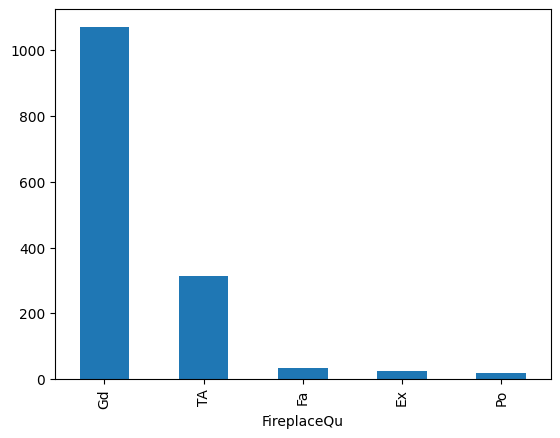

In [56]:
ok['FireplaceQu'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'FirePlaceQu')

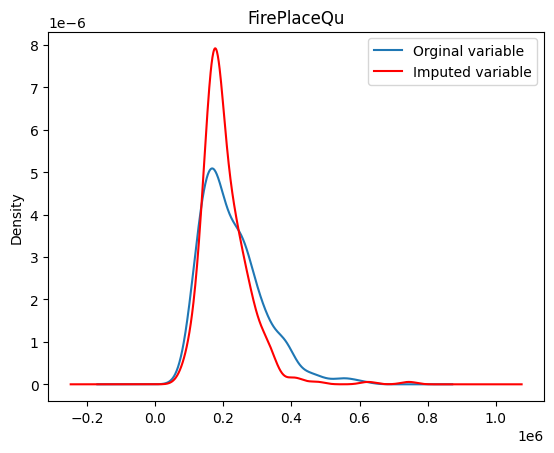

In [59]:
fig =plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)

# distribution of the variable after imputation
ok[ok['FireplaceQu']=='TA']['SalePrice'].plot(kind='kde',ax=ax,color='red')



lines,labels= ax.get_legend_handles_labels()
labels=['Orginal variable','Imputed variable']
ax.legend(lines,labels,loc='best')

plt.title('FirePlaceQu')

In [61]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(ok.drop(columns=['SalePrice']),ok['SalePrice'],test_size=0.3)

In [62]:
from sklearn.impute import SimpleImputer


In [63]:
impute = SimpleImputer(strategy='most_frequent')

In [64]:
x_train =impute.fit_transform(x_train)
x_test =impute.fit(x_test)

In [66]:
impute.statistics_

array(['Gd', 'TA'], dtype=object)